In [2]:
import utils
import numpy as np
import matplotlib.pyplot as plt

import scienceplots
import matplotlib.patheffects as pe
plt.style.use(['science', 'nature', 'notebook', 'grid', 'high-vis'])
cmap = 'jet'


figsize_short = (8, 4)
figsize_normal = (8, 6)
figsize_tall = (8, 8)
plt.rcParams['figure.figsize'] = figsize_short
plt.rcParams['axes.labelpad'] = 6.0
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.8
plt.rcParams['legend.edgecolor'] = 'none'


title_font = {'fontsize': 16, 'weight': 'bold', 'style': 'italic'}
path_effect = [pe.withStroke(linewidth=2.0, foreground="k")]

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10512\4260687943.py:47: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(t[-1], 1, 0, 0.33, color = '#888888', edgecolor = 'none', zorder = 2)


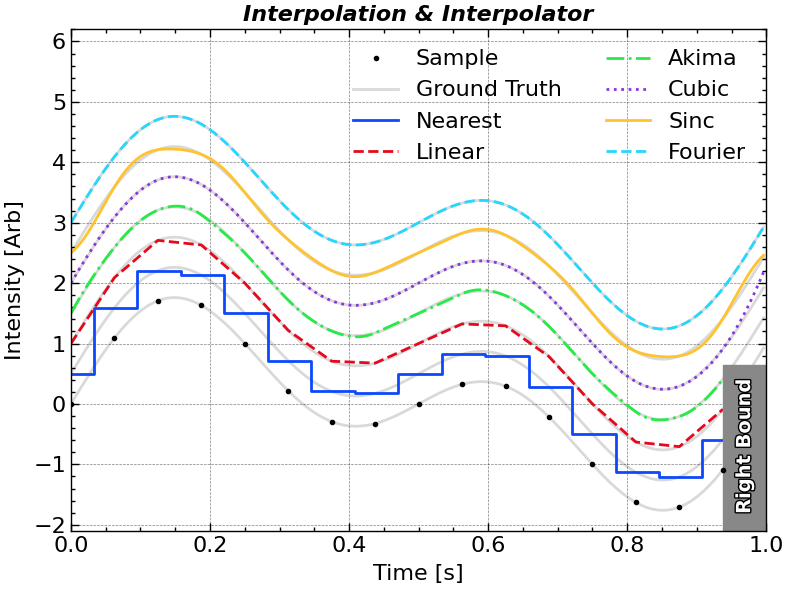

In [7]:
import importlib
importlib.reload(utils)

import scipy.interpolate

plt.close()
plt.figure(figsize=(8, 6), tight_layout=True)
ax1 = plt.subplot(1, 1, 1)
N = 2 ** 4
omega0 = 2 * np.pi * 1

t = np.arange(0, N + 1) / N
t = np.linspace(0, 1, N, endpoint = False)

dt = t[1] - t[0]
sig = np.sin(omega0 * t) + np.sin(omega0 * 2 * t)

ax1.plot(t, sig, 'ko', label = 'Sample', zorder = 3)

nearest_interp = scipy.interpolate.interp1d(t, sig, kind = 'nearest', bounds_error = False)
linear_interp = scipy.interpolate.interp1d(t, sig, bounds_error = False)
akima_interp = scipy.interpolate.Akima1DInterpolator(t, sig)
cubic_interp = scipy.interpolate.CubicSpline(t, sig)

def sinc_interp(t_interp):
    weight = np.sinc((t_interp[:, None] - t[None, :]) / dt)
    return weight @ sig

n_interp = 2 ** 4 * N
t_interp = np.arange(0, n_interp) / n_interp

gap = 0.5
sig_interp = np.sin(omega0 * t_interp) + np.sin(omega0 * 2 * t_interp)
for i in range(7):
    if i == 0:
        ax1.plot(t_interp, sig_interp + i * gap, 'k-', alpha = 0.15, label = 'Ground Truth')
    else:
        ax1.plot(t_interp, sig_interp + i * gap, 'k-', alpha = 0.15)

ax1.step(t_interp, nearest_interp(t_interp) + 1 * gap, label = 'Nearest', where = 'mid')
ax1.plot(t_interp, linear_interp(t_interp) + 2 * gap, label = 'Linear')
ax1.plot(t_interp, akima_interp(t_interp) + 3 * gap, label = 'Akima')
ax1.plot(t_interp, cubic_interp(t_interp) + 4 * gap, label = 'Cubic')
ax1.plot(t_interp, sinc_interp(t_interp) + 5 * gap, label = 'Sinc')
ax1.plot(t_interp, scipy.signal.resample(sig, t_interp.size) + 6 * gap, label = 'Fourier')

ax1.axvspan(t[-1], 1, 0, 0.33, color = '#888888', edgecolor = 'none', zorder = 2)
ax1.text((t[-1] + 1) / 2, -0.7, 'Right Bound', rotation = 90,          fontsize=14,
         color='w',
         ha='center',
         va='center',
         weight='bold', path_effects = path_effect)
ax1.autoscale(axis = 'x', tight = True)

ax1.legend(frameon = False, ncol = 2, loc = 'upper right')
ax1.set_title('Interpolation & Interpolator', **title_font)

ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Intensity [Arb]')
ax1.set_ylim(-2.1, 6.2)

plt.tight_layout()
# ax1.grid('off')


plt.show()

In [77]:
import bottleneck as bn

import importlib

import utils.resample
importlib.reload(utils.resample)

from utils.resample import create_uniform_grid

import numpy as np

N = 30
# ==== 1. Perfectly uniform ====
x1 = np.arange(0, N, 1.0)
xu1 = create_uniform_grid(x1)
print("Case 1 (perfect uniform):", x1, xu1)

# ==== 2. Small jitter (±0.05), still approximately uniform ====
rng = np.random.default_rng(0)
x2 = np.arange(0, N, 1.0) + rng.normal(0, 1e-2, N)
xu2 = create_uniform_grid(x2)
print("Case 2 (small jitter):", x2, xu2)

# ==== 3. Missing a few points (2 missing points, below max_missing_ratio) ====
x3 = np.delete(np.arange(0, N, 1.0), [5, 12])
xu3 = create_uniform_grid(x3)
print("Case 3 (few missing):", x3, xu3)

# ==== 4. Jitter too large → Does not satisfy tol_jitter, should return False ====
x4 = np.arange(0, N, 1.0)
x4[5] += 0.8  # Introduce significant jitter
xu4 = create_uniform_grid(x4)
print("Case 4 (too large jitter):", x4, xu4)

# ==== 5. Too many missing points (> max_missing_ratio) → Should return False ====
x5 = np.delete(np.arange(0, N, 1.0), np.arange(0, N, 3))  # Remove 1/3
xu5 = create_uniform_grid(x5)
print("Case 5 (too many missing):", x5, xu5)

# ==== 6. Not strictly increasing → Should return False ====
x6 = np.array([0, 1, 2, 2, 3, 4])  # Contains duplicates
xu6 = create_uniform_grid(x6)
print("Case 6 (non-increasing):", x6, xu6)


Case 1 (perfect uniform): [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.] [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.]
Case 2 (small jitter): [1.25730221e-03 9.98678951e-01 2.00640423e+00 3.00104900e+00
 3.99464331e+00 5.00361595e+00 6.01304000e+00 7.00947081e+00
 7.99296265e+00 8.98734579e+00 9.99376726e+00 1.10004133e+01
 1.19767497e+01 1.29978121e+01 1.39875409e+01 1.49926773e+01
 1.59945574e+01 1.69968370e+01 1.80041163e+01 1.90104251e+01
 1.99987147e+01 2.10136646e+01 2.19933481e+01 2.30035151e+01
 2.40090347e+01 2.50009401e+01 2.59925650e+01 2.69907827e+01
 2.79954227e+01 2.90022020e+01] [1.25730221e-03 1.00353689e+00 2.00581648e+00 3.00809607e+00
 4.01037566e+00 5.01265524e+00 6.01493483e+00 7.01721442e+00
 8.01949401e+00 9.02177360e+00 1.00240532e+01 1.10263328e+01
 1.20286124e+01 1.30308919e+01 1.40331715e+01 1.50354511e+01
 1

C:\Users\Administrator\AppData\Local\Temp\ipykernel_37184\3372018075.py:34: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(t[-1], 1, 0, 0.33, color = '#888888', edgecolor = 'none', zorder = 2)


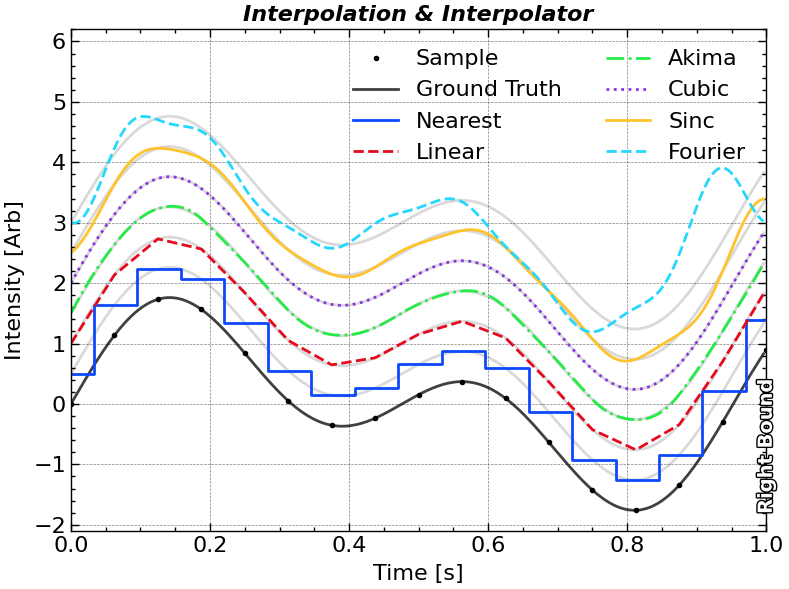

In [ ]:
import utils.resample
importlib.reload(utils.resample)

plt.close()
plt.figure(figsize=(8, 6), tight_layout=True)
ax1 = plt.subplot(1, 1, 1)
N = 2 ** 4
omega0 = 2 * np.pi * 1.05

t = np.linspace(0, 1, N + 1, endpoint = True)

sig = np.sin(omega0 * t) + np.sin(omega0 * 2 * t)

ax1.plot(t, sig, 'ko', label = 'Sample', zorder = 3)

n_interp = 2 ** 4 * N
t_interp = np.arange(0, n_interp) / n_interp

gap = 0.5
sig_interp = np.sin(omega0 * t_interp) + np.sin(omega0 * 2 * t_interp)
for i in range(7):
    if i == 0:
        ax1.plot(t_interp, sig_interp + i * gap, 'k-', alpha = 0.75, label = 'Ground Truth')
    else:
        ax1.plot(t_interp, sig_interp + i * gap, 'k-', alpha = 0.15)

ax1.step(t_interp, utils.resample.resample(t, sig, t_interp, 'nearest') + 1 * gap, label = 'Nearest', where = 'mid')
ax1.plot(t_interp, utils.resample.resample(t, sig, t_interp, 'linear') + 2 * gap, label = 'Linear')
ax1.plot(t_interp, utils.resample.resample(t, sig, t_interp, 'akima') + 3 * gap, label = 'Akima')
ax1.plot(t_interp, utils.resample.resample(t, sig, t_interp, 'cubic') + 4 * gap, label = 'Cubic')
ax1.plot(t_interp, utils.resample.resample(t, sig, t_interp, 'sinc') + 5 * gap, label = 'Sinc')

_sig = np.copy(sig)
_slope = (_sig[-1] - _sig[0]) / (t[-1] - t[0])
_sig -= _slope * (t - t[0])

ax1.plot(t_interp, scipy.signal.resample(sig, t_interp.size) + 6 * gap, label = 'Fourier')

ax1.axvspan(t[-1], 1, 0, 0.33, color = '#888888', edgecolor = 'none', zorder = 2)
ax1.text((t[-1] + 1) / 2, -0.7, 'Right Bound', rotation = 90,          fontsize=14,
         color='w',
         ha='center',
         va='center',
         weight='bold', path_effects = path_effect)
ax1.autoscale(axis = 'x', tight = True)

ax1.legend(frameon = False, ncol = 2, loc = 'upper right')
ax1.set_title('Interpolation & Interpolator', **title_font)

ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Intensity [Arb]')
ax1.set_ylim(-2.1, 6.2)

plt.tight_layout()
# ax1.grid('off')

plt.show()

Help on ufunc in module numpy:

rint = <ufunc 'rint'>
    rint(x, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])

    Round elements of the array to the nearest integer.

    Parameters
    ----------
    x : array_like
        Input array.
    out : ndarray, None, or tuple of ndarray and None, optional
        A location into which the result is stored. If provided, it must have
        a shape that the inputs broadcast to. If not provided or None,
        a freshly-allocated array is returned. A tuple (possible only as a
        keyword argument) must have length equal to the number of outputs.
    where : array_like, optional
        This condition is broadcast over the input. At locations where the
        condition is True, the `out` array will be set to the ufunc result.
        Elsewhere, the `out` array will retain its original value.
        Note that if an uninitialized `out` array is created via the default
        ``out=None